In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
min(len(w) for w in words)

2

In [4]:
max(len(w) for w in words)

15

In [5]:
b = {}
for w in words:
    w = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(w, w[1:]):
        biagram = (ch1, ch2)
        b[biagram] = b.get(biagram, 0) + 1


In [6]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [7]:
import torch

In [8]:
N = torch.zeros((26 + 1, 26 + 1), dtype=torch.int32)

In [9]:
chars = sorted(list(set(''.join(words))))
s2i = {s: i+1 for i, s in enumerate(chars)}
s2i['.'] = 0
i2s = {i: s for s, i in s2i.items()}

In [10]:
for w in words:
    w = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(w, w[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        N[ix1, ix2] += 1

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

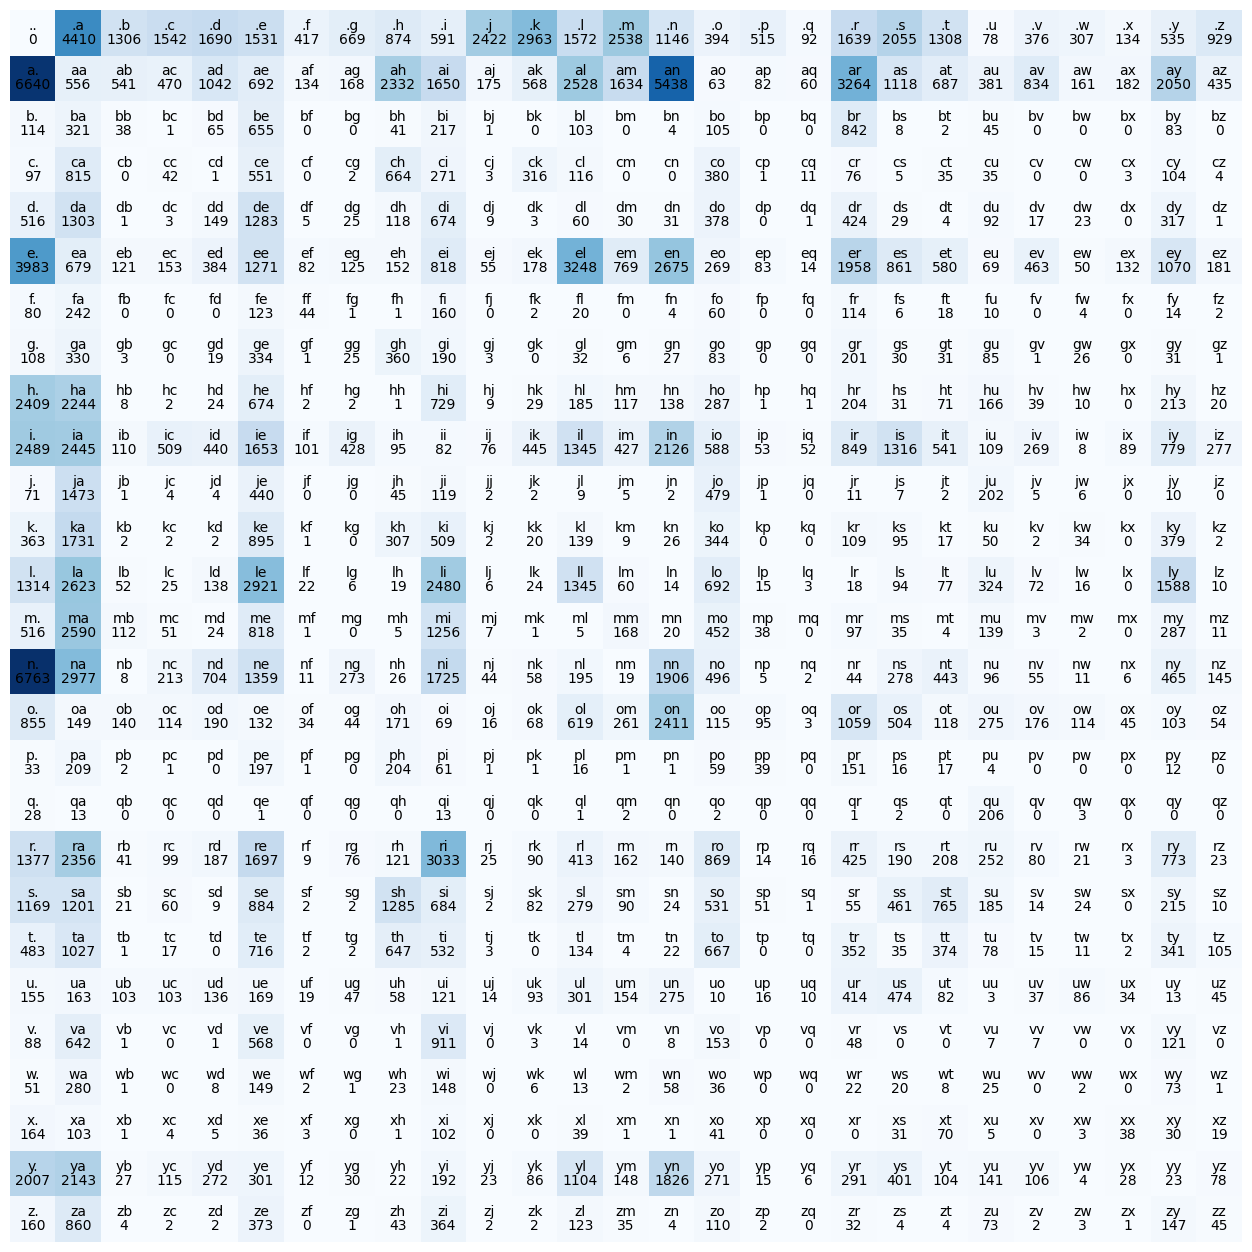

In [14]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = i2s[i] + i2s[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="black")
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color="black")
plt.axis('off')        

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

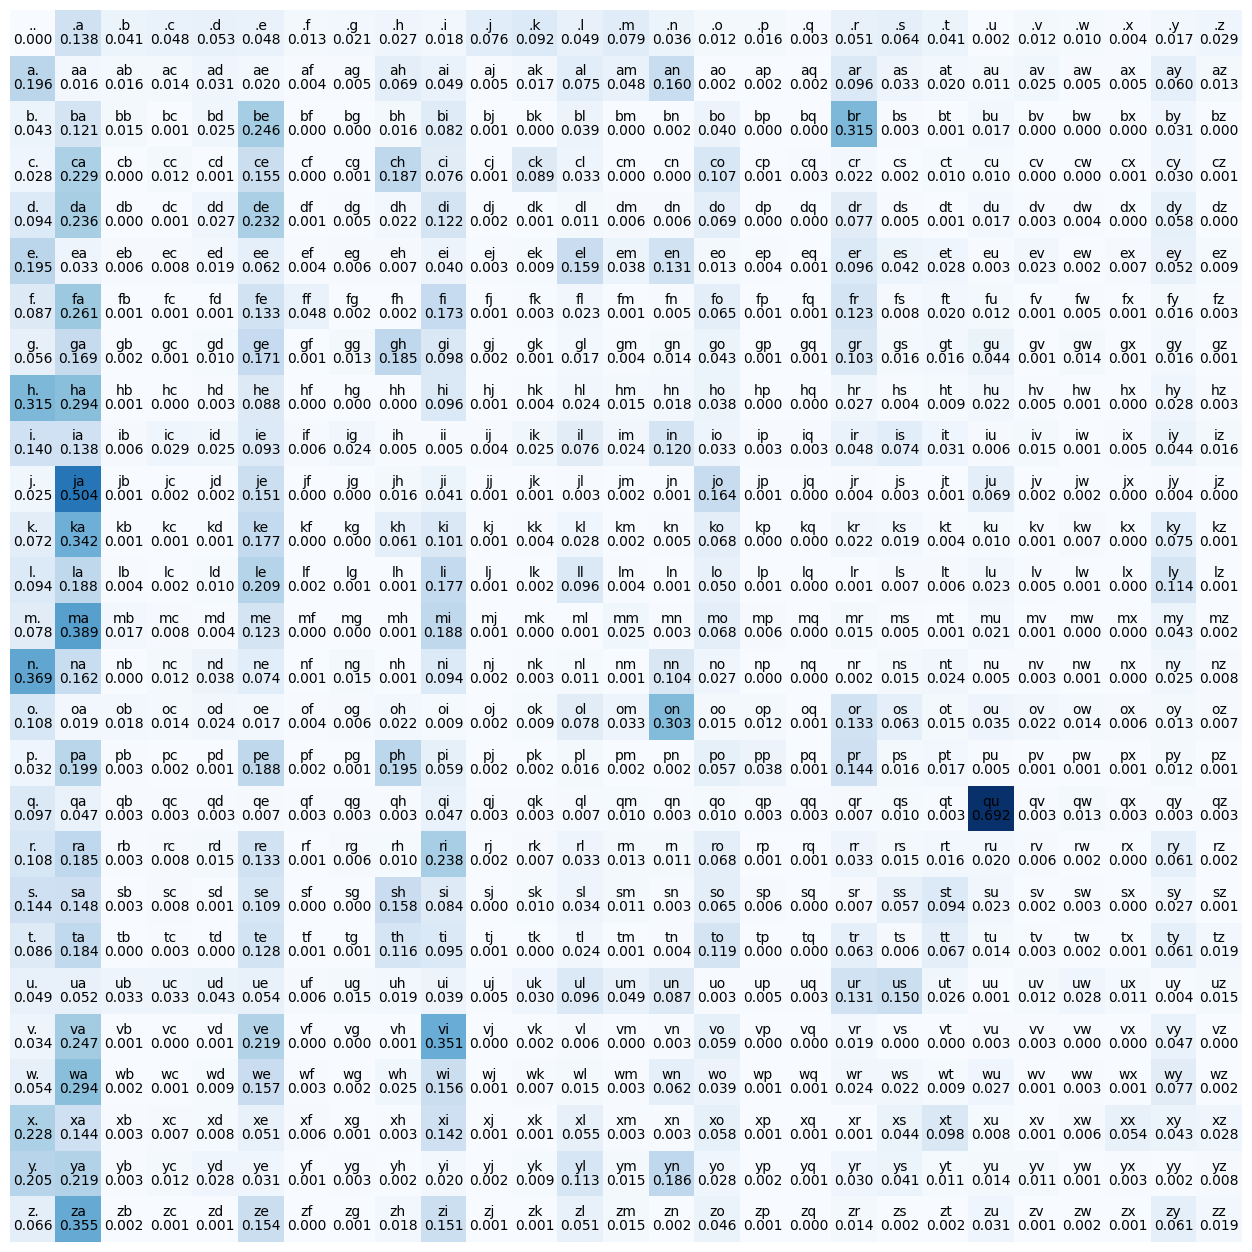

In [23]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = i2s[i] + i2s[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="black")
        plt.text(j, i, f"{P[i,j].item():.3f}", ha="center", va="top", color="black", wrap=True)
plt.axis('off')    

In [24]:
g = torch.Generator().manual_seed(80085)
index = 0

for i in range(50):
    out = []
    while True:
        p = P[index]
        index = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if index == 0:
            break
        out.append(i2s[index])
    print(''.join(out))

zelltzau
mo
aisleraylynaran
ah
yreystarielish
nassiarr
ahiyraislan
ce
kyl
hirmah
n
ce
ayaidrilibryall
raicari
adelell
a
m
drivaylyelera
keebrorysieline
sur
fayayanienn
nzatosusels
meevewmirkoruli
belelion
eral
jah
alimmalyaaman
brayllaxtaythosaylmaiyn
tharyara
prokret
eroh
wyaa
cenah
preriarahafa
nd
jarimr
jeveray
lynahayayri
kiyin
bdhei
dryahzamen
riya
jamisoysslekylivinehriyn
han
jahllantyanin
zelanti
jin
n
c
asaliutligiaorlerylee


In [25]:
log_likelihood = 0.00
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        prob = P[ix1, ix2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {log_prob:.4f}')
nll = -log_likelihood
print(f'LL: {log_likelihood} | NNL: {nll} | Avg NNL: {nll / n}')

LL: -559951.5625 | NNL: 559951.5625 | Avg NNL: 2.4543561935424805


In [27]:
xs, ys = [], []

for w in words:
    w = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(w, w[1:]):
        ix1 = s2i[ch1]
        ix2 = s2i[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)